In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import sys
import os

# Add parent directory to sys.path
parent_dir = os.path.abspath(os.path.join(os.getcwd(), os.pardir))
sys.path.append(parent_dir)

In [3]:
from package_files.benefits_defns import *

In [4]:
path_all = '../data/us_10m_nointernship_2018_2024_benefits.parquet.gzip'

In [5]:
usdf = pd.read_parquet(path_all)

In [6]:
df_select = usdf[benefits4+['SALARY']].copy()

In [7]:
df_select

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,SALARY
0,False,False,False,False,False,False,37440.0
1,False,False,False,False,False,False,30160.0
2,False,False,False,False,False,False,NaN
3,False,False,False,False,False,False,NaN
4,False,False,False,False,False,False,NaN
...,...,...,...,...,...,...,...
9872911,False,False,False,False,False,False,NaN
9872912,True,False,False,False,False,False,NaN
9872913,False,False,False,False,False,False,NaN
9872914,False,False,False,False,False,False,NaN


In [8]:
df_salary = df_select[df_select['SALARY'].notnull()]

In [9]:
correlation_matrix = df_salary.corr()

In [10]:
correlation_matrix

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,SALARY
EDU_ASSISTANCE,1.000000,0.272956,0.152597,0.243685,0.087478,0.023262,0.009432
PAID_LEAVE,0.272956,1.000000,0.162652,0.235157,0.046721,0.017448,-0.029390
HEALTH_WELLBEING,0.152597,0.162652,1.000000,0.160524,0.073469,0.050535,0.029834
PARENTAL_LEAVE,0.243685,0.235157,0.160524,1.000000,0.136347,0.084723,0.066448
CULTURE,0.087478,0.046721,0.073469,0.136347,1.000000,0.074840,0.104308
REMOTE_KW,0.023262,0.017448,0.050535,0.084723,0.074840,1.000000,0.187108
SALARY,0.009432,-0.029390,0.029834,0.066448,0.104308,0.187108,1.000000


([<matplotlib.axis.YTick at 0x7f9f1557cec0>,
 [Text(0, 0.5, 'Tuition Assistance'),
  Text(0, 1.5, 'Paid Leave'),
  Text(0, 2.5, 'Health and Wellbeing'),
  Text(0, 3.5, 'Parental Leave'),
  Text(0, 4.5, 'Workplace Culture'),
  Text(0, 5.5, 'Remote Work'),
  Text(0, 6.5, 'Salary')])

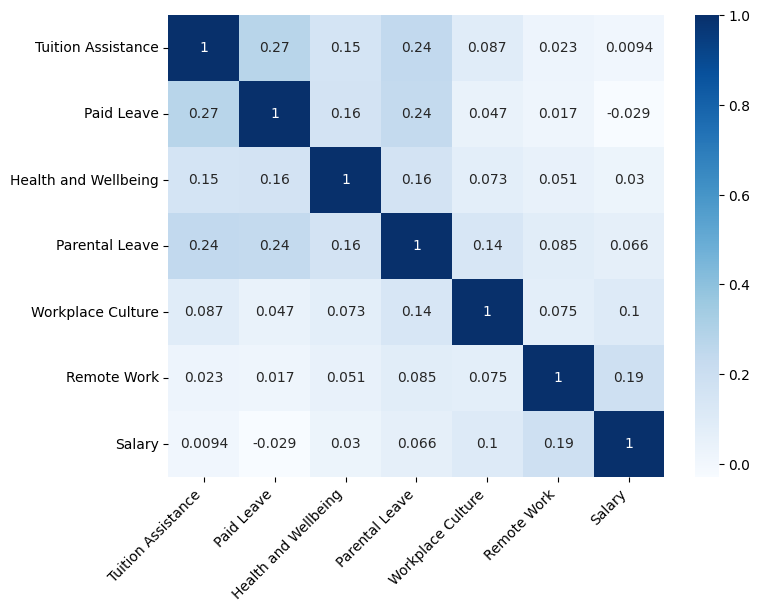

In [11]:
plt.figure(figsize=(8,6))
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', cbar = True)
plt.xticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=45, ha='right')
plt.yticks(ticks=np.arange(len(correlation_matrix.columns))+0.5, labels=benefits4_labels + ['Salary'], rotation=0, va='center')

# Benefit Count

In [12]:
df_select['Benefit Count'] = df_select[benefits4].sum(axis=1)

In [13]:
df_select

,EDU_ASSISTANCE,PAID_LEAVE,HEALTH_WELLBEING,PARENTAL_LEAVE,CULTURE,REMOTE_KW,SALARY,Benefit Count
0,False,False,False,False,False,False,37440.0,0
1,False,False,False,False,False,False,30160.0,0
2,False,False,False,False,False,False,NaN,0
3,False,False,False,False,False,False,NaN,0
4,False,False,False,False,False,False,NaN,0
...,...,...,...,...,...,...,...,...
9872911,False,False,False,False,False,False,NaN,0
9872912,True,False,False,False,False,False,NaN,1
9872913,False,False,False,False,False,False,NaN,0
9872914,False,False,False,False,False,False,NaN,0


In [14]:
df_select['Benefit Count'].value_counts()

Benefit Count
0    6221806
1    2462412
2     805149
3     279295
4      85285
5      16444
6       2525
Name: count, dtype: int64

<Axes: xlabel='Benefit Count', ylabel='Count'>

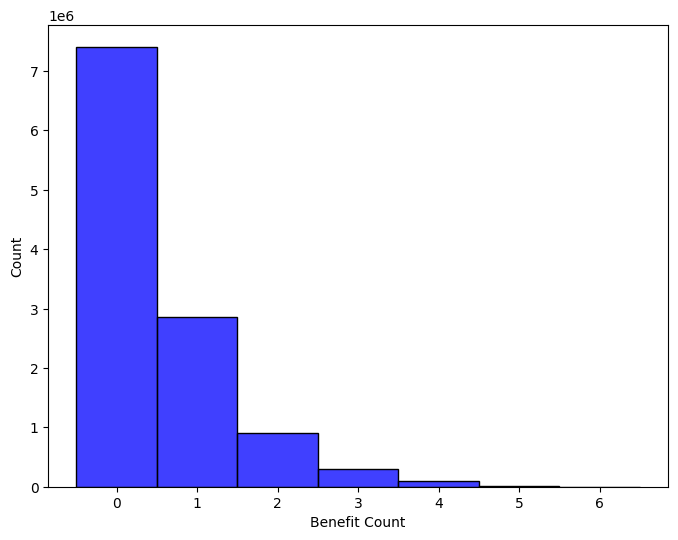

In [32]:
# plot Benefit Count
plt.figure(figsize=(8,6))
sns.histplot(df_select['Benefit Count'], bins=range(0,6), discrete=True, color='blue')

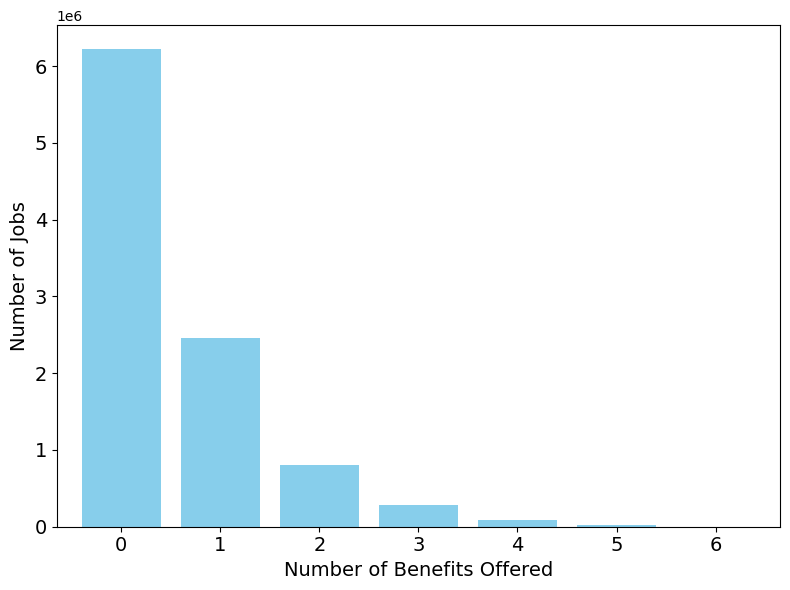

In [16]:
import matplotlib.pyplot as plt

# Assuming df_select is your DataFrame and 'Benefit Count' is already created
# Count the number of rows for each unique value in 'Benefit Count'
benefit_count_distribution = df_select['Benefit Count'].value_counts().sort_index()

# Plot the distribution as a bar chart
plt.figure(figsize=(8, 6))
ax = benefit_count_distribution.plot(kind='bar', color='skyblue', width=0.8)  # Adjust width to reduce space between bars
# ax.ticklabel_format(style='plain', axis='y')
ax.set_xticklabels(benefit_count_distribution.index.astype(int), rotation = 0, fontsize = 14)
ax.yaxis.set_tick_params(labelsize=14)


# Add labels and title
# plt.title('Number of Rows per Benefit Count', fontsize=16)
plt.xlabel('Number of Benefits Offered', fontsize=14)
plt.ylabel('Number of Jobs', fontsize=14)

# Show the plot
plt.tight_layout()
plt.savefig('../figures/compounding_effects/num_jobs_num_benefits_2024.png')
plt.show()
